   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


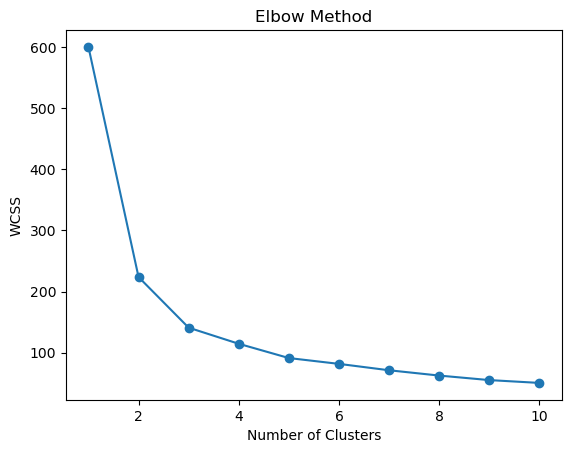

Silhouette Score for k=2: 0.580184463257396
Silhouette Score for k=3: 0.4589717867018717
Silhouette Score for k=4: 0.38528456243462456
Silhouette Score for k=5: 0.34726464875461055
   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1


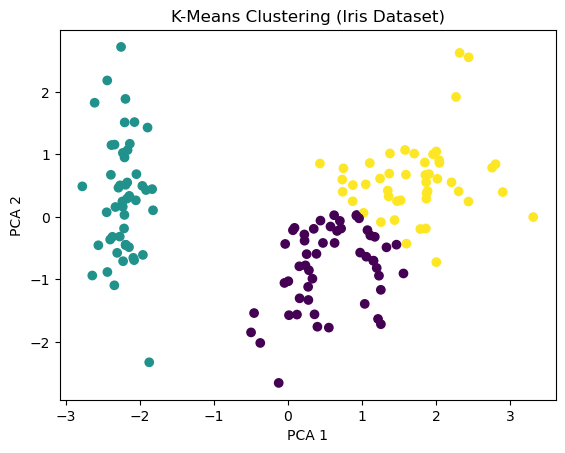

In [5]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ================== LOAD DATASET ==================
df = pd.read_csv("iris.csv")

# Check dataset
print(df.head())
print(df.columns)

# ================== DATA PREPROCESSING ==================
# Keep only numeric columns (safe method)
X = df.select_dtypes(include=[np.number])

# ================== FEATURE SCALING ==================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================== ELBOW METHOD ==================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ================== SILHOUETTE SCORE ==================
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score for k={k}: {score}")

# ================== APPLY K-MEANS ==================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['Cluster'] = clusters

print(df.head())

# ================== PCA FOR VISUALIZATION ==================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ================== VISUALIZE CLUSTERS ==================
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clustering (Iris Dataset)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()